In [1]:
import pandas as pd
import numpy as np
import os

#visuals
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [2]:
#load data
exo_planets_df = pd.read_csv("exo_planets_clean.csv")
koi_df = pd.read_csv("koi_clean.csv")
solor_df = pd.read_csv("solar_clean.csv")
merged_df = pd.read_csv("merged_planetary_data.csv")

In [3]:
merged_df.columns
merged_df.head(10)

,pl_name,pl_orbper,pl_orbsmax,pl_orbeccen,pl_rade,pl_bmasse,st_teff,st_rad,st_mass,st_met,pl_eqt,pl_insol,origin
0,11 Com b,323.21000,1.178,0.238,NaN,4914.898486,4874.0,13.76,2.09,-0.26,NaN,NaN,Exoplanet
1,11 Com b,NaN,1.210,NaN,NaN,5434.700000,NaN,NaN,2.60,NaN,NaN,NaN,Exoplanet
2,11 Com b,326.03000,1.290,0.231,NaN,6165.600000,4742.0,19.00,2.70,-0.35,NaN,NaN,Exoplanet
3,11 UMi b,NaN,1.510,NaN,NaN,3432.400000,NaN,NaN,1.70,NaN,NaN,NaN,Exoplanet
4,11 UMi b,516.22000,1.540,0.080,NaN,3337.070000,4340.0,24.08,1.80,0.04,NaN,NaN,Exoplanet
5,11 UMi b,516.21997,1.530,0.080,NaN,4684.814200,4213.0,29.79,2.78,-0.02,NaN,NaN,Exoplanet
6,14 And b,185.84000,0.830,0.000,NaN,1525.500000,4813.0,11.00,2.20,-0.24,NaN,NaN,Exoplanet
7,14 And b,186.76000,0.775,0.000,NaN,1131.151301,4888.0,11.55,1.78,-0.21,NaN,NaN,Exoplanet
8,14 And b,NaN,0.680,NaN,NaN,1017.000000,NaN,NaN,1.20,NaN,NaN,NaN,Exoplanet
9,14 Her b,1773.40000,2.770,0.369,NaN,1474.670000,NaN,NaN,NaN,NaN,NaN,NaN,Exoplanet


In [4]:
merged_df.columns

Index(['pl_name', 'pl_orbper', 'pl_orbsmax', 'pl_orbeccen', 'pl_rade',
       'pl_bmasse', 'st_teff', 'st_rad', 'st_mass', 'st_met', 'pl_eqt',
       'pl_insol', 'origin'],
      dtype='object')

 #compared how each dataset differ 
1. Distribution-Based Questions
  .Which group (Solar, KOI, Exoplanet) tends to have the largest planets?
  .Are the orbital periods in the Solar System longer or shorter than what we detect in exoplanets?
  .Do Solar planets fall within the same temperature range as most exoplanets?

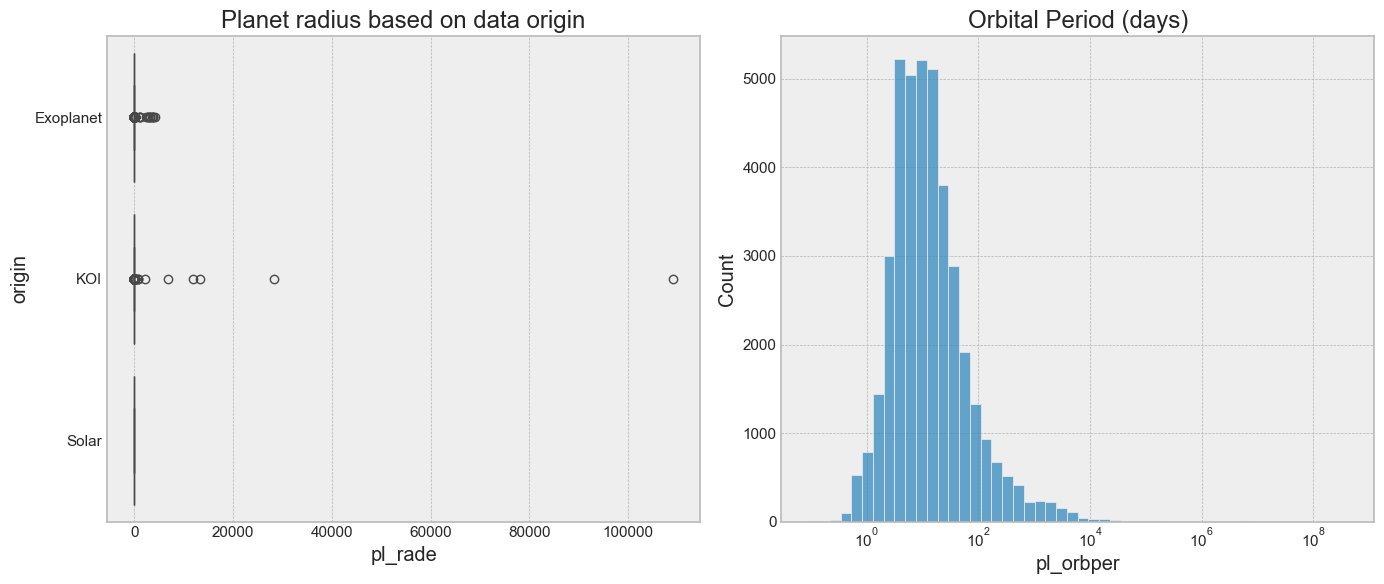

Text(0.5, 1.0, 'Do Solar planets fall within the same temperature range as most exoplanets?')

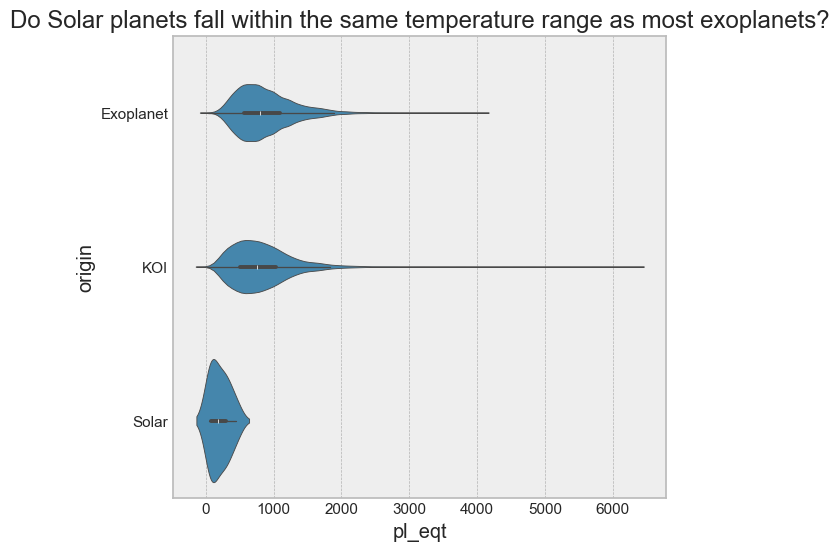

In [5]:
plt.style.use('bmh')

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=merged_df,x="pl_rade",y="origin")
plt.title("Planet radius based on data origin")

plt.subplot(1, 2, 2)
sns.histplot(merged_df["pl_orbper"].dropna(), bins=50, log_scale=True)
plt.title("Orbital Period (days)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.violinplot(data=merged_df,x="pl_eqt",y="origin")
plt.title("Do Solar planets fall within the same temperature range as most exoplanets?")

In [6]:
merged_df.columns

Index(['pl_name', 'pl_orbper', 'pl_orbsmax', 'pl_orbeccen', 'pl_rade',
       'pl_bmasse', 'st_teff', 'st_rad', 'st_mass', 'st_met', 'pl_eqt',
       'pl_insol', 'origin'],
      dtype='object')

2. Outlier & Extremes Thinking
Is Earth an outlier in any feature or the Sun?
What planet is the largest or most eccentric? Is it Solar or Exoplanet?

In [7]:
# Find the most extreme values and who they belong to
features = ['pl_bmasse', 'pl_orbper', 'pl_rade', 'pl_orbeccen']

for feature in features:
    print(f"\n🔹 Max {feature}:")
    print(merged_df.loc[merged_df[feature].idxmax(), ['pl_name', feature, 'origin']])
    
    print(f"🔹 Min {feature}:")
    print(merged_df.loc[merged_df[feature].idxmin(), ['pl_name', feature, 'origin']])



🔹 Max pl_bmasse:
pl_name          PH2 b
pl_bmasse      25426.4
origin       Exoplanet
Name: 35365, dtype: object
🔹 Min pl_bmasse:
pl_name      Mercury
pl_bmasse        0.0
origin         Solar
Name: 43234, dtype: object

🔹 Max pl_orbper:
pl_name      COCONUTS-2 b
pl_orbper     402000000.0
origin          Exoplanet
Name: 237, dtype: object
🔹 Min pl_orbper:
pl_name      PSR J1719-1438 b
pl_orbper            0.090706
origin              Exoplanet
Name: 35385, dtype: object

🔹 Max pl_rade:
pl_name         NaN
pl_rade    109061.0
origin          KOI
Name: 42602, dtype: object
🔹 Min pl_rade:
pl_name    Mercury
pl_rade    0.00003
origin       Solar
Name: 43234, dtype: object

🔹 Max pl_orbeccen:
pl_name        HD 20782 b
pl_orbeccen          0.97
origin          Exoplanet
Name: 2811, dtype: object
🔹 Min pl_orbeccen:
pl_name        KOI-351 h
pl_orbeccen       -0.011
origin         Exoplanet
Name: 6450, dtype: object


In [8]:
earth_values = {
    'pl_bmasse': 1.0,
    'pl_orbper': 365.25,  # days
    'pl_rade': 1.0,
    'pl_orbeccen': 0.017,
    'pl_eqt': 255,  # average Earth equilibrium temp in K
    'pl_orbsmax': 1.0  # AU
   
}
numeric_cols = [
    'pl_orbper', 'pl_orbsmax', 'pl_orbeccen', 'pl_rade', 
    'pl_bmasse', 'st_teff', 'st_rad', 'st_mass', 
    'st_met', 'pl_eqt'
]

# Calculate the median for each feature, grouped by 'origin'
group_medians = merged_df.groupby('origin')[numeric_cols].median()

# Isolate the medians for the Exoplanet group
exoplanet_medians = group_medians.loc['Exoplanet']

print("--- Percentage Difference of Exoplanet Median vs. The Earth ---\n")

# Loop through each feature and calculate the percentage difference
for feature, earth_values in earth_values.items():
    # Get the median value for the current feature from the exoplanet group
    exoplanet_median = exoplanet_medians[feature]
    
   

    # Calculate percentage difference
    percentage_diff = ((exoplanet_median - earth_values) / earth_values) * 100
    
    # Print the results in a readable format
    print(f"Feature: {feature}")
    print(f"  - Exoplanet Median: {exoplanet_median:.2f}")
    print(f"  - Earth's Value: {earth_values}")
    print(f"  - Difference: {percentage_diff:+.2f}%\n")

--- Percentage Difference of Exoplanet Median vs. The Earth ---

Feature: pl_bmasse
  - Exoplanet Median: 197.05
  - Earth's Value: 1.0
  - Difference: +19605.36%

Feature: pl_orbper
  - Exoplanet Median: 10.36
  - Earth's Value: 365.25
  - Difference: -97.16%

Feature: pl_rade
  - Exoplanet Median: 2.29
  - Earth's Value: 1.0
  - Difference: +129.00%

Feature: pl_orbeccen
  - Exoplanet Median: 0.00
  - Earth's Value: 0.017
  - Difference: -100.00%

Feature: pl_eqt
  - Exoplanet Median: 795.00
  - Earth's Value: 255
  - Difference: +211.76%

Feature: pl_orbsmax
  - Exoplanet Median: 0.10
  - Earth's Value: 1.0
  - Difference: -89.95%



In [9]:
earth_values = {
    'pl_bmasse': 1.0,
    'pl_orbper': 365.25,  # days
    'pl_rade': 1.0,
    'pl_orbeccen': 0.017,
    'pl_eqt': 255,  # average Earth equilibrium temp in K
    'pl_orbsmax': 1.0  # AU
   
}
numeric_cols = [
    'pl_orbper', 'pl_orbsmax', 'pl_orbeccen', 'pl_rade', 
    'pl_bmasse', 'st_teff', 'st_rad', 'st_mass', 
    'st_met', 'pl_eqt'
]

# Calculate the median for each feature, grouped by 'origin'
group_medians = merged_df.groupby('origin')[numeric_cols].median()

# Isolate the medians for the Exoplanet group
koi_medians = group_medians.loc['KOI']

print("--- Percentage Difference of Exoplanet Median vs. The Earth ---\n")

# Loop through each feature and calculate the percentage difference
for feature, earth_values in earth_values.items():
    # Get the median value for the current feature from the exoplanet group
    koi_val  = koi_medians[feature]

    if pd.notna(koi_val):
        percentage_diff = ((koi_val - earth_values) / earth_values) * 100
        print(f"🔹 Feature: {feature}")
        print(f"    - Earth:      {earth_values}")
        print(f"    - KOI Median: {koi_val:.4f}")
        print(f"    - Difference: {percentage_diff:+.2f}%\n")
    else:
        print(f"🔹 Feature: {feature} — Missing KOI median.\n")
   

    # Calculate percentage difference
    percentage_diff = ((koi_val - earth_values) / earth_values) * 100
    
    # Print the results in a readable format
    print(f"Feature: {feature}")
    print(f"  - Exoplanet Median: {koi_val:.2f}")
    print(f"  - Earth's Value: {earth_values}")
    print(f"  - Difference: {percentage_diff:+.2f}%\n")

--- Percentage Difference of Exoplanet Median vs. The Earth ---

🔹 Feature: pl_bmasse — Missing KOI median.

Feature: pl_bmasse
  - Exoplanet Median: nan
  - Earth's Value: 1.0
  - Difference: +nan%

🔹 Feature: pl_orbper
    - Earth:      365.25
    - KOI Median: 13.3669
    - Difference: -96.34%

Feature: pl_orbper
  - Exoplanet Median: 13.37
  - Earth's Value: 365.25
  - Difference: -96.34%

🔹 Feature: pl_rade
    - Earth:      1.0
    - KOI Median: 2.0100
    - Difference: +101.00%

Feature: pl_rade
  - Exoplanet Median: 2.01
  - Earth's Value: 1.0
  - Difference: +101.00%

🔹 Feature: pl_orbeccen — Missing KOI median.

Feature: pl_orbeccen
  - Exoplanet Median: nan
  - Earth's Value: 0.017
  - Difference: +nan%

🔹 Feature: pl_eqt
    - Earth:      255
    - KOI Median: 752.0000
    - Difference: +194.90%

Feature: pl_eqt
  - Exoplanet Median: 752.00
  - Earth's Value: 255
  - Difference: +194.90%

🔹 Feature: pl_orbsmax — Missing KOI median.

Feature: pl_orbsmax
  - Exoplanet Median:

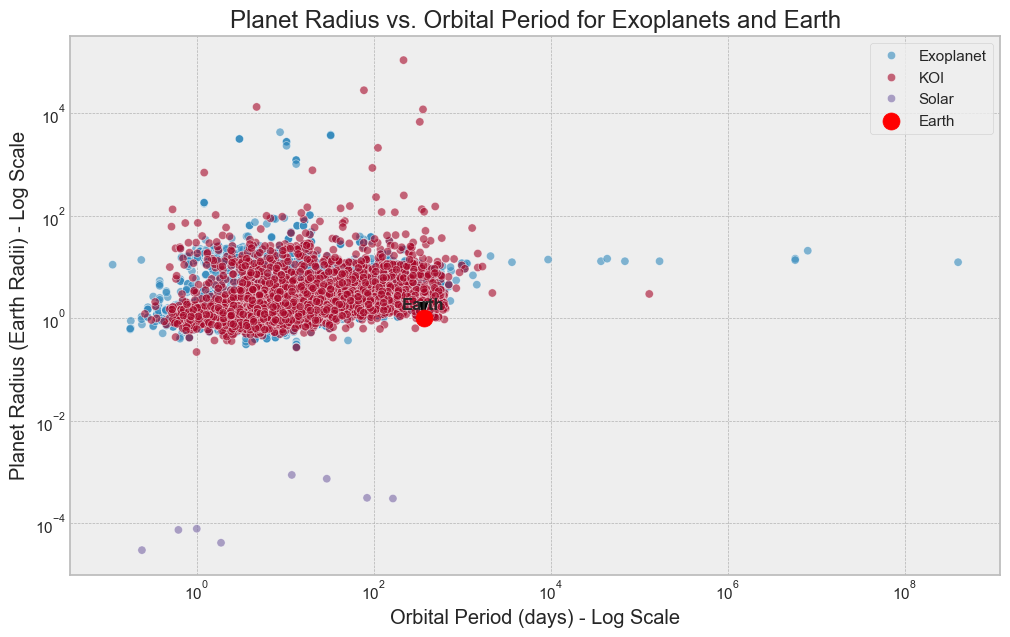

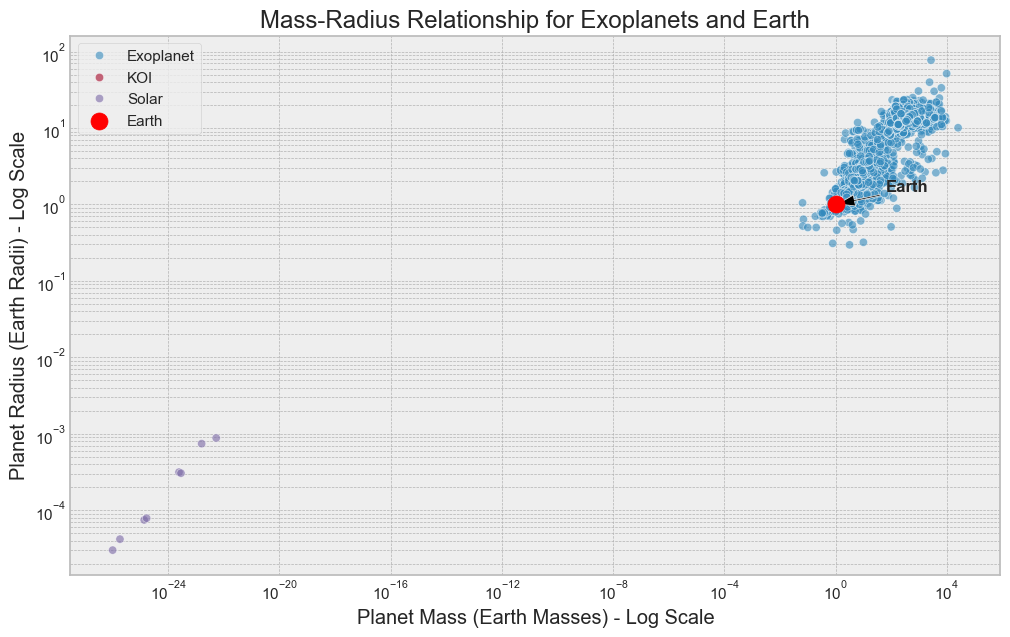

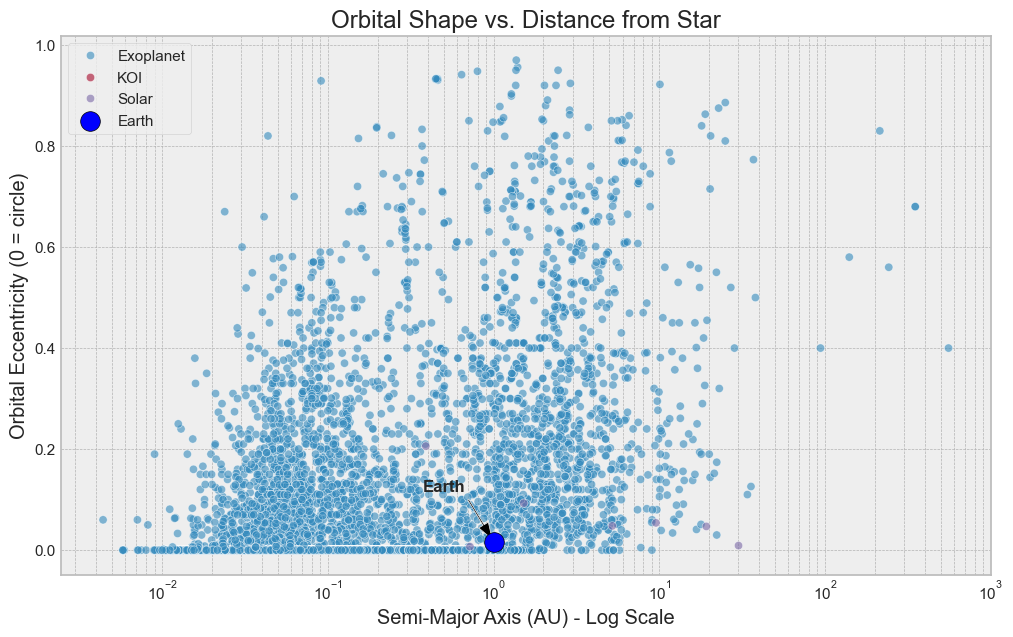

In [10]:
plt.style.use('bmh')
# Create the scatter plot
plt.figure(figsize=(12, 7))
sns.scatterplot(data=merged_df, x="pl_orbper", y="pl_rade", hue="origin", alpha=0.6)

# Add and annotate the Earth data point
earth_orb_period = 365.25
earth_radius = 1.0
plt.scatter(earth_orb_period, earth_radius, color='red', s=150, label="Earth", zorder=5)
plt.annotate(
    'Earth',
    xy=(earth_orb_period, earth_radius),
    xytext=(earth_orb_period, earth_radius * 1.5),
    ha='center',
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
    fontsize=12,
    fontweight='bold'
)

# Set plot scales and labels for better visualization
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Orbital Period (days) - Log Scale")
plt.ylabel("Planet Radius (Earth Radii) - Log Scale")
plt.title("Planet Radius vs. Orbital Period for Exoplanets and Earth")
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)

plt.figure(figsize=(12, 7))
earth_mass = 1.0
sns.scatterplot(data=merged_df, x="pl_bmasse", y="pl_rade", hue="origin", alpha=0.6)
plt.scatter(earth_mass, earth_radius, color='red', s=150, label="Earth", zorder=5)
plt.annotate(
    'Earth',
    xy=(earth_mass, earth_radius),
    xytext=(earth_orb_period, earth_radius * 1.5),
    ha='center',
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
    fontsize=12,
    fontweight='bold'
)

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Planet Mass (Earth Masses) - Log Scale")
plt.ylabel("Planet Radius (Earth Radii) - Log Scale")
plt.title("Mass-Radius Relationship for Exoplanets and Earth")
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)



plt.figure(figsize=(12, 7))

# Create the scatter plot for exoplanet data
sns.scatterplot(data=merged_df, x="pl_orbsmax", y="pl_orbeccen", hue="origin", alpha=0.6)

# Add and annotate the Earth data point
earth_smax = 1.0
earth_eccen = 0.0167
plt.scatter(earth_smax, earth_eccen, color='blue', s=200, label="Earth", zorder=5, ec='black')
plt.annotate(
    'Earth',
    xy=(earth_smax, earth_eccen),
    xytext=(earth_smax * 0.5, earth_eccen + 0.1), # Position text for clarity
    ha='center',
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
    fontsize=12,
    fontweight='bold'
)

# Set plot scales and labels
plt.xscale('log')
plt.xlabel("Semi-Major Axis (AU) - Log Scale")
plt.ylabel("Orbital Eccentricity (0 = circle)")
plt.title("Orbital Shape vs. Distance from Star")
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)


In [11]:

# Create Sun reference row
sun_data = {
    'pl_name': 'SunRef',
    'pl_orbper': np.nan,
    'pl_orbsmax': np.nan,
    'pl_orbeccen': np.nan,
    'pl_rade': np.nan,
    'pl_bmasse': np.nan,
    'st_teff': 5778,
    'st_rad': 1.0,
    'st_mass': 1.0,
    'st_met': 0.0,
    'origin': 'Sun'
}

# Append to combined_df
merged_df = pd.concat([merged_df, pd.DataFrame([sun_data])], ignore_index=True)
star_features = ['st_teff', 'st_rad', 'st_mass', 'st_met']

for feature in star_features:
    print(f"\n Max {feature}:")
    print(merged_df.loc[merged_df[feature].idxmax(), ['pl_name', feature, 'origin']])

    print(f" Min {feature}:")
    print(merged_df.loc[merged_df[feature].idxmin(), ['pl_name', feature, 'origin']])



 Max st_teff:
pl_name     NN Ser c
st_teff      57000.0
origin     Exoplanet
Name: 34959, dtype: object
 Min st_teff:
pl_name    WISE J033605.05-014350.4 b
st_teff                         415.0
origin                      Exoplanet
Name: 38267, dtype: object

 Max st_rad:
pl_name        NaN
st_rad     152.969
origin         KOI
Name: 42019, dtype: object
 Min st_rad:
pl_name    ZTF J1230-2655 b
st_rad               0.0123
origin            Exoplanet
Name: 38381, dtype: object

 Max st_mass:
pl_name    HAT-P-35 b
st_mass         23.56
origin      Exoplanet
Name: 1218, dtype: object
 Min st_mass:
pl_name    MOA-2011-BLG-262L b
st_mass                 0.0031
origin               Exoplanet
Name: 34820, dtype: object

 Max st_met:
pl_name    TOI-1408 b
st_met           7.79
origin      Exoplanet
Name: 35722, dtype: object
 Min st_met:
pl_name    Kepler-1071 b
st_met              -2.5
origin         Exoplanet
Name: 7752, dtype: object


In [12]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43243 entries, 0 to 43242
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pl_name      41263 non-null  object 
 1   pl_orbper    40031 non-null  float64
 2   pl_orbsmax   21693 non-null  float64
 3   pl_orbeccen  18507 non-null  float64
 4   pl_rade      31181 non-null  float64
 5   pl_bmasse    6683 non-null   float64
 6   st_teff      39919 non-null  float64
 7   st_rad       40155 non-null  float64
 8   st_mass      32696 non-null  float64
 9   st_met       24480 non-null  float64
 10  pl_eqt       21454 non-null  float64
 11  pl_insol     21464 non-null  float64
 12  origin       43243 non-null  object 
dtypes: float64(11), object(2)
memory usage: 4.3+ MB


In [13]:
sun_values ={  'st_teff': 5778,
    'st_rad': 1.0,
    'st_mass': 1.0,
    'st_met': 0.0}

numeric_cols = [
    'pl_orbper', 'pl_orbsmax', 'pl_orbeccen', 'pl_rade', 
    'pl_bmasse', 'st_teff', 'st_rad', 'st_mass', 
    'st_met', 'pl_eqt'
]

# Calculate the median for each feature, grouped by 'origin'
group_medians = merged_df.groupby('origin')[numeric_cols].median()

# Isolate the medians for the Exoplanet group
exoplanet_medians = group_medians.loc['Exoplanet']

print("--- Percentage Difference of Exoplanet Median vs. The Sun ---\n")

# Loop through each feature and calculate the percentage difference
for feature, sun_value in sun_values.items():
    # Get the median value for the current feature from the exoplanet group
    exoplanet_median = exoplanet_medians[feature]
    
    # Handle the special case for metallicity where the Sun's value is 0
    if feature == 'st_met' and sun_value == 0:
        print(f"Stellar Metallicity (st_met):")
        print(f"  - Sun's Value: {sun_value}")
        print(f"  - Exoplanet Median: {exoplanet_median:.2f}")
        print("  - Percentage difference is not meaningful when the reference is 0.\n")
        continue

    # Calculate percentage difference
    percentage_diff = ((exoplanet_median - sun_value) / sun_value) * 100
    
    # Print the results in a readable format
    print(f"Feature: {feature}")
    print(f"  - Exoplanet Median: {exoplanet_median:.2f}")
    print(f"  - Sun's Value: {sun_value}")
    print(f"  - Difference: {percentage_diff:+.2f}%\n")

--- Percentage Difference of Exoplanet Median vs. The Sun ---

Feature: st_teff
  - Exoplanet Median: 5614.00
  - Sun's Value: 5778
  - Difference: -2.84%

Feature: st_rad
  - Exoplanet Median: 0.95
  - Sun's Value: 1.0
  - Difference: -4.90%

Feature: st_mass
  - Exoplanet Median: 0.96
  - Sun's Value: 1.0
  - Difference: -4.00%

Stellar Metallicity (st_met):
  - Sun's Value: 0.0
  - Exoplanet Median: -0.01
  - Percentage difference is not meaningful when the reference is 0.



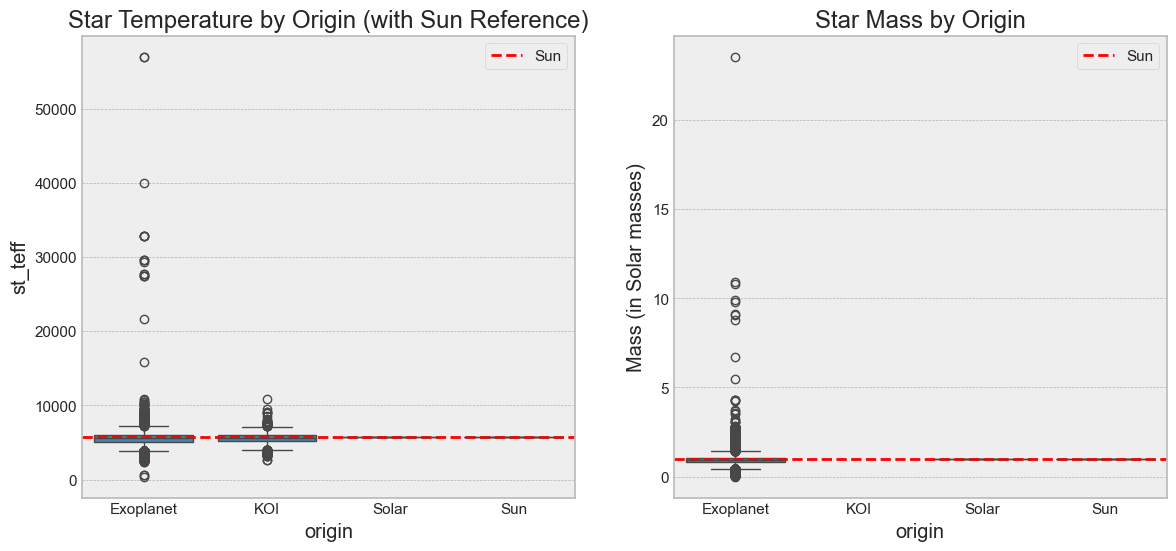

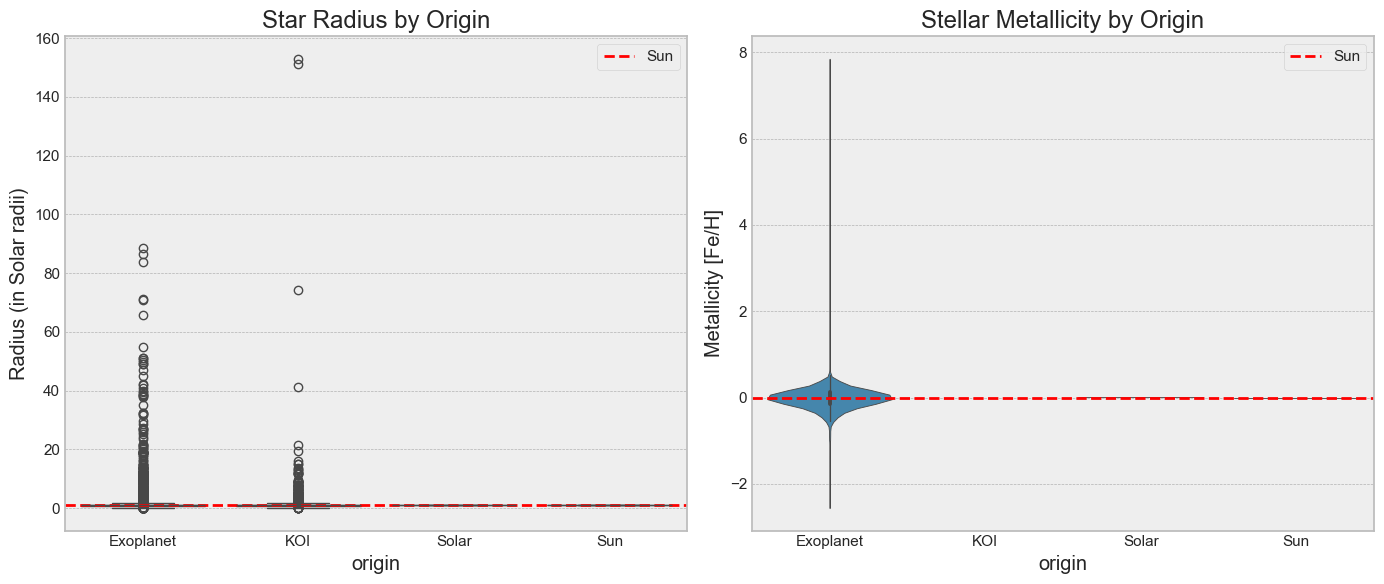

In [14]:
plt.style.use('bmh')
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=merged_df, x="origin", y="st_teff")
plt.axhline(5778, color='red', linestyle='--', label='Sun')
plt.legend()
plt.title("Star Temperature by Origin (with Sun Reference)")


plt.subplot(1, 2, 2)
sns.boxplot(data=merged_df, x="origin", y="st_mass")
plt.axhline(1.0, color='red', linestyle='--', label='Sun')
plt.title("Star Mass by Origin")
plt.ylabel("Mass (in Solar masses)")
plt.legend()


plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=merged_df, x="origin", y="st_rad")
plt.axhline(1.0, color='red', linestyle='--', label='Sun')
plt.title("Star Radius by Origin")
plt.ylabel("Radius (in Solar radii)")
plt.legend()


plt.subplot(1, 2, 2)
sns.violinplot(data=merged_df, x="origin", y="st_met")
plt.axhline(0.0, color='red', linestyle='--', label='Sun')
plt.title("Stellar Metallicity by Origin")
plt.ylabel("Metallicity [Fe/H]")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\bunho\AppData\Local\Temp\ipykernel_6964\2119763803.py:2: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


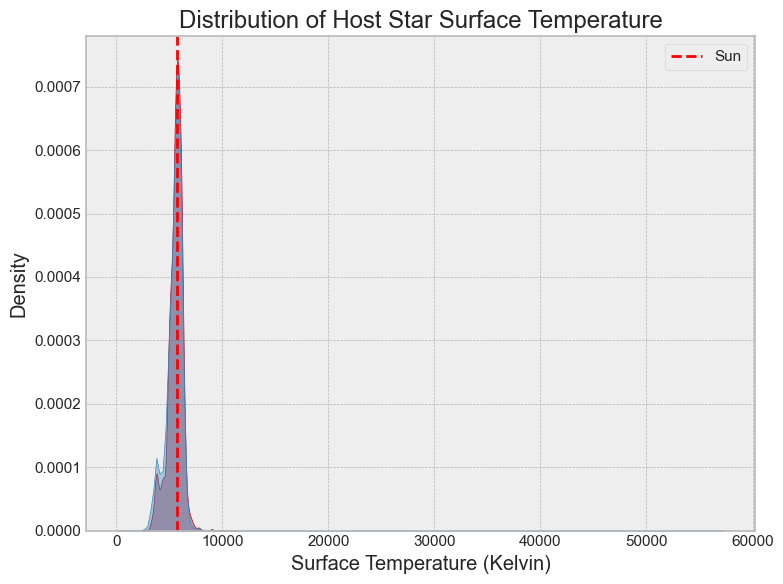

In [15]:
plt.figure(figsize=(8, 6))
sns.kdeplot(
    data=merged_df,
    x='st_teff',
    hue='origin',
    fill=True,
    common_norm=False,
    alpha=0.4
)

# Mark the Sun's temperature
plt.axvline(5778, color='red', linestyle='--', label='Sun')

# Labels and title
plt.title("Distribution of Host Star Surface Temperature")
plt.xlabel("Surface Temperature (Kelvin)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

3. Habitability Check
 Basic Requirements 
1. Distance between host star
2. Not have low mass and rotate along its axis
3. Planets temperature in habitable zone

In [16]:
# Run check on dataset to see if any planets meets the requirements
def check_habitability(
    df,
    min_mass=0.8,
    max_mass=1.2,
    temp_range=(273, 300),            # Near liquid water range
    insol_range=(0.75, 1.25),         # Around Earth's solar flux
    dist_range=(0.95, 1.37),
    star_temp_range=(5500, 6000),
    rotation_column='rotation_period'
):
    """
    Returns planets that closely resemble Earth across mass, temperature, insolation, and host star.
    """
    hab_df = df.copy()

    # Drop missing values from relevant fields
    hab_df = hab_df.dropna(subset=[
        'pl_bmasse', 'pl_eqt', 'pl_insol', 'pl_orbsmax', 'st_teff'
    ])

    # 1. Mass close to Earth's
    hab_df = hab_df[hab_df['pl_bmasse'].between(min_mass, max_mass)]

    # 2. Equilibrium temperature near Earth
    hab_df = hab_df[hab_df['pl_eqt'].between(*temp_range)]

    # 3. Insolation near Earth’s
    hab_df = hab_df[hab_df['pl_insol'].between(*insol_range)]

    # 4. Host star temp & planet-star distance
    hab_df = hab_df[
        hab_df['pl_orbsmax'].between(*dist_range) &
        hab_df['st_teff'].between(*star_temp_range)
    ]

    return hab_df

In [17]:
hab_df = check_habitability(merged_df)

In [18]:
hab_df.columns

Index(['pl_name', 'pl_orbper', 'pl_orbsmax', 'pl_orbeccen', 'pl_rade',
       'pl_bmasse', 'st_teff', 'st_rad', 'st_mass', 'st_met', 'pl_eqt',
       'pl_insol', 'origin'],
      dtype='object')

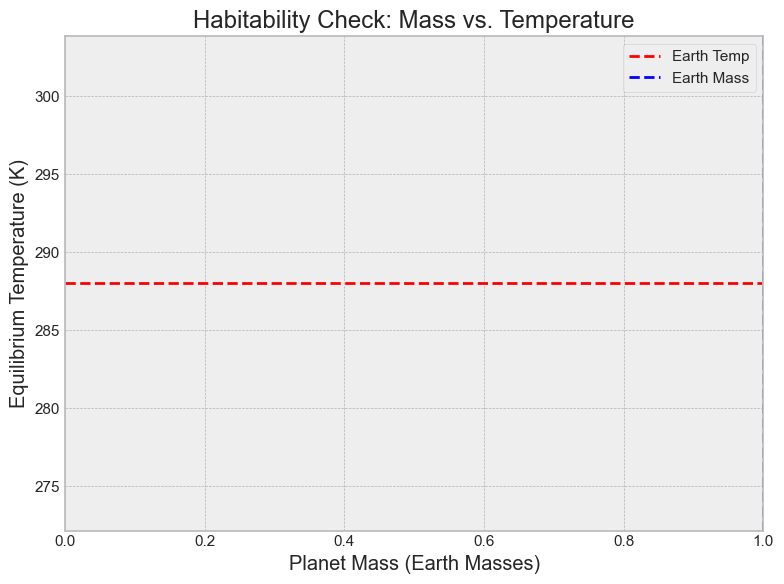

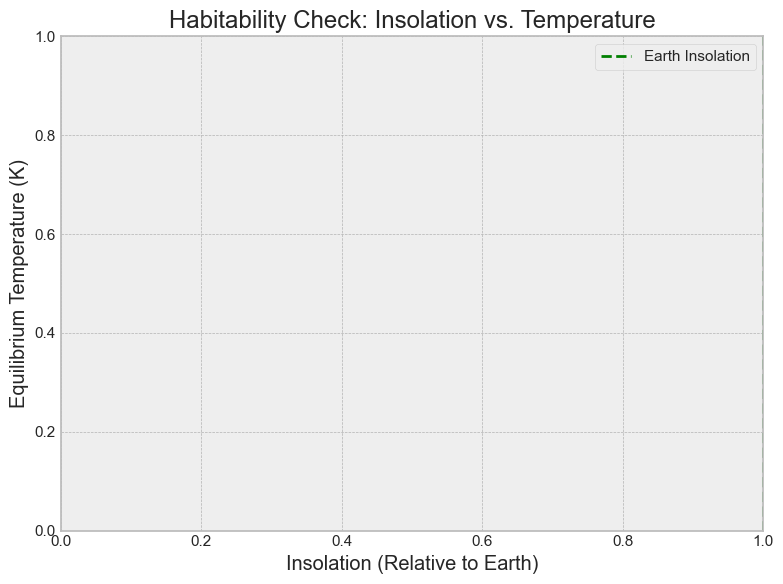

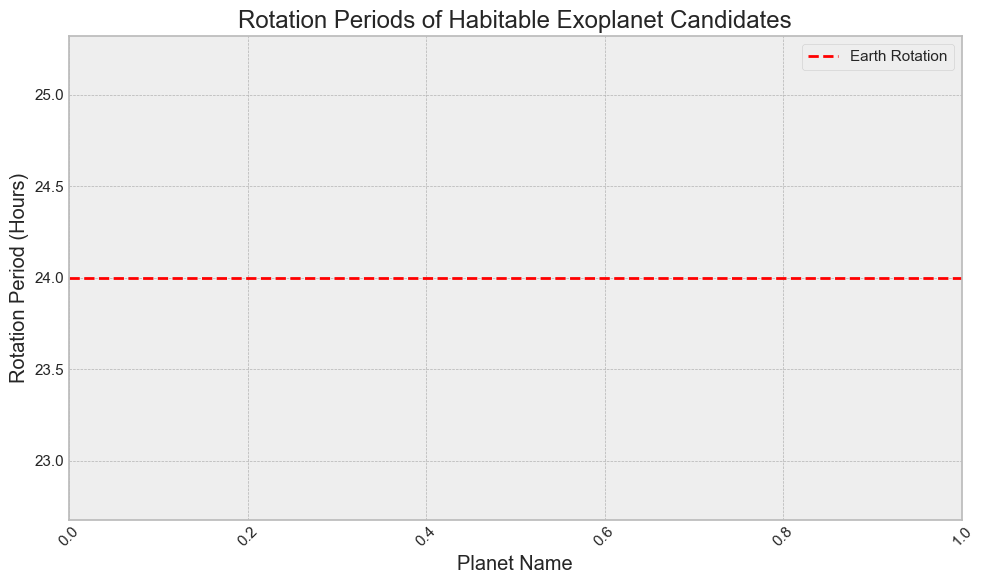

In [19]:
# visualize potential planets to ours

# Define Earth-like thresholds 
mass_tol = 0.3
temp_tol = 20
insol_tol = 0.3



# Plot 1: Mass vs. Equilibrium Temperature
plt.figure(figsize=(8, 6))
sns.scatterplot(data= hab_df, x='pl_bmasse', y='pl_eqt', hue='pl_name', s=100, edgecolor='black')
plt.axhline(288, color='red', linestyle='--', label='Earth Temp')
plt.axvline(1.0, color='blue', linestyle='--', label='Earth Mass')
plt.title('Habitability Check: Mass vs. Temperature')
plt.xlabel('Planet Mass (Earth Masses)')
plt.ylabel('Equilibrium Temperature (K)')
plt.legend()
plt.tight_layout()

# Plot 2: Insolation vs. Temperature
plt.figure(figsize=(8, 6))
sns.scatterplot(data=hab_df, x='pl_insol', y='pl_eqt', hue='origin', s=100, edgecolor='black')
plt.axvline(1.0, color='green', linestyle='--', label='Earth Insolation')
plt.title('Habitability Check: Insolation vs. Temperature')
plt.xlabel('Insolation (Relative to Earth)')
plt.ylabel('Equilibrium Temperature (K)')
plt.legend()
plt.tight_layout()

# Plot 3: Rotation Period Comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=hab_df, x='pl_name', y='pl_orbper', palette='Blues_d')
plt.axhline(24.0, color='red', linestyle='--', label='Earth Rotation')
plt.title('Rotation Periods of Habitable Exoplanet Candidates')
plt.ylabel('Rotation Period (Hours)')
plt.xlabel('Planet Name')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
hab_df

,pl_name,pl_orbper,pl_orbsmax,pl_orbeccen,pl_rade,pl_bmasse,st_teff,st_rad,st_mass,st_met,pl_eqt,pl_insol,origin


There no planets habitably like earth